# DATA CLEANING TEKNON CLINICAL DATA
**Content of the file:** This file contains all the preprocessing steps to clean, impute and structure the Teknon clinical variables. Cleaning meaning mainly handeling NaN values and the imputation strategies.

### Imports and Paths

In [1]:
'''# If executing from google colab, uncomment these lines
from google.colab import drive
drive.mount('/content/drive')
base_path = '/content/drive/Shareddrives/CompBioMed/seminars/'
'''

Mounted at /content/drive


In [2]:
import pickle
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

base_path = ''
data = pickle.load(open(os.path.join(base_path, 'data/full_data_corrected_2024.pkl'), 'rb'))
labels_path = os.path.join(base_path, 'data/labels_FontiersUnsupervised.xlsx')
labels2_path = os.path.join(base_path, 'data/label2.xlsx')


### Explore the data
Here a small exploration of the data is done, also the technical corrections are applied. Like transposing, indexing, encoding or handling cells with more than one value.

In [3]:
# Transpose the data twice to ensure the correct orientation (rows= Patients, columns=features)
data = pd.DataFrame(data).T
data = pd.DataFrame(data).T

# Reset the index and set the identifier column
data = data.reset_index().rename(columns={'index': 'patient_id'})

# Define column groups
ecg_cols = ['I','II','III','AVR','AVL','AVF','V1','V2','V3','V4','V5','V6']
clinical_cols = ['Sex','HTA','Age','PVC_transition','Height','Weight','BMI',
    'DM','DLP','Smoker','COPD','Sleep_apnea','CLINICAL_SCORE']
label_cols = ['SOO_chamber','SOO','OTorigin']

# create sub-dataframes for localized inspection
ecg = data[ecg_cols].copy()
clinical = data[clinical_cols].copy()
labels = data[label_cols].copy()

In [4]:
# Remove elements that were incorrectly written
def remove_lists(x):
    if isinstance(x, list):

        if len(x) == 1:
           # If there is one value, it is kept
          return x[0]

        elif len(x) == 0:
          # Empty lists become Nan values
          return np.nan

          # If there is more than one, they are joined into a string
        else:
          return ', '.join(str(i) for i in x)
    return x

# Apply to the whole dataframe
data = data.applymap(remove_lists)
X = data[clinical_cols]
y = data[label_cols]

/tmp/ipykernel_6453/3725652414.py:19: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  data = data.applymap(remove_lists)


In [5]:
# Convert cathegorical features to binary
def convert_to_binary(value, true_value, false_value):
    if pd.isna(value):
        return None
    elif value == true_value:
        return 1
    elif value == false_value:
        return 0
    return None # Unexpected or empty values

# Apply the function above to the binary labels
data['Sex'] = data['Sex'].apply(lambda x: convert_to_binary(x, 'Female', 'Male'))
data['HTA'] = data['HTA'].apply(lambda x: convert_to_binary(x, 'Yes', 'No'))
data['DM'] = data['DM'].apply(lambda x: convert_to_binary(x, 'Yes', 'No'))
data['DLP'] = data['DLP'].apply(lambda x: convert_to_binary(x, 'Yes', 'No'))
data['Smoker'] = data['Smoker'].apply(lambda x: convert_to_binary(x, 'Yes', 'No'))
data['COPD'] = data['COPD'].apply(lambda x: convert_to_binary(x, 'Yes', 'No'))
data['Sleep_apnea'] = data['Sleep_apnea'].apply(lambda x: convert_to_binary(x, 'Yes', 'No'))

display(data[clinical_cols + label_cols].head())

,Sex,HTA,Age,PVC_transition,Height,Weight,BMI,DM,DLP,Smoker,COPD,Sleep_apnea,CLINICAL_SCORE,SOO_chamber,SOO,OTorigin
0,1.0,NaN,61.0,V1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Right ventricle,Unión mitroaórtica,0.0
1,1.0,0.0,52.0,V3,169.0,68.0,NaN,0.0,0.0,0.0,0.0,0.0,1.0,RVOT,Pared libre anterior,1.0
2,1.0,0.0,69.0,V3,156.0,70.0,NaN,0.0,1.0,0.0,0.0,0.0,1.0,LVOT,RCC,1.0
3,1.0,0.0,66.0,V4,176.0,63.0,20.338326,0.0,0.0,0.0,0.0,0.0,1.0,Right ventricle,M. papilar posteromedial,0.0
4,1.0,1.0,46.0,V3,160.0,79.0,30.859375,0.0,0.0,0.0,0.0,0.0,1.0,RVOT,RVOT septal,1.0


In [6]:
important_cols = [
    'Age',
    'Sex',
    'PVC_transition'
]

all_clinical_cols = [
    'HTA','DM','DLP','Smoker','COPD','Sleep_apnea',
    'Height','Weight','BMI','CLINICAL_SCORE'
]

# threshold = 0.5  # 50% mínimo de datos clínicos no críticos

In [7]:
# limpiar None
data[clinical_cols] = data[clinical_cols].replace("None", np.nan)

In [8]:
data["missing_rate"] = data[all_clinical_cols].isna().mean(axis=1) # calcula porcentaje de vacios (NaN) de los all clinical cols

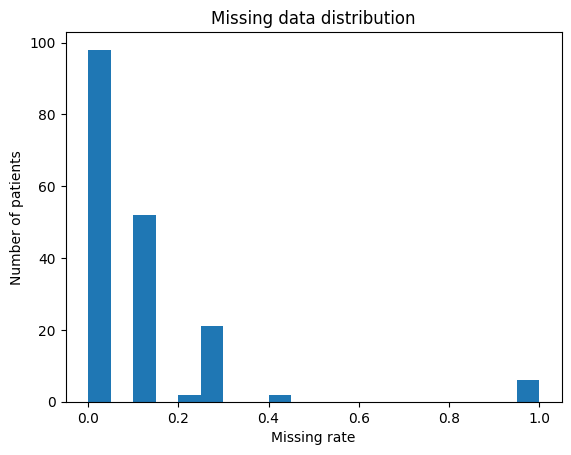

In [9]:
threshold = 0.5

plt.hist(data["missing_rate"], bins=20)
plt.xlabel("Missing rate")
plt.ylabel("Number of patients")
plt.title("Missing data distribution")
plt.show()

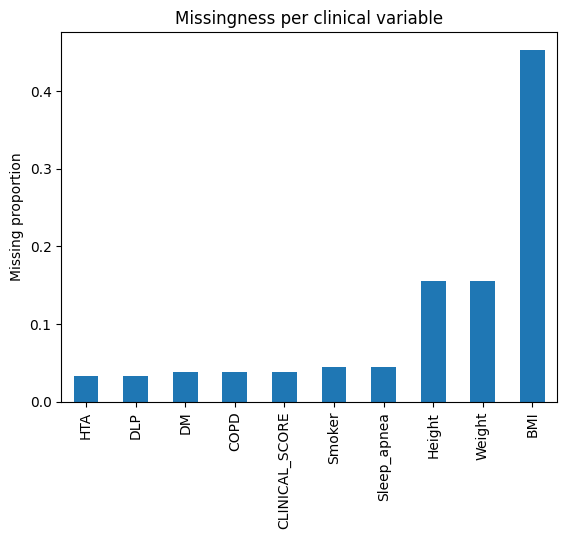

In [10]:
data[all_clinical_cols].isna().mean().sort_values().plot(kind="bar")
plt.ylabel("Missing proportion")
plt.title("Missingness per clinical variable")
plt.show()

### Missing Clinical Values
The following variables are considered highly important because:
* Age influences the type of arrhythmic substrate (RVOT vs. LVOT).
* Sex can modify the distribution of ventricular origins.
* PVC_transition is a key electrocardiographic variable for differentiating between right and left origin.

Therefore, age has been imputed using the mean, and the PVC_transition has been calculated based on the table data for those patients who did not have it explicitly recorded. Regarding sex, it has been left blank in 2 cases.

The following are considered secondary clinical variables:
* HTA: arterial hypertension (high blood pressure)
* DM: diabetes mellitus
* DLP: dyslipidemia (high cholesterol/triglycerides)
* Smoker: smoker statusCOPD: chronic obstructive pulmonary disease
* Sleep_apnea: sleep apnea
* Height: height (cm)
* Weight: weight (kg)
* BMI: body mass index ($\text{weight} / \text{height}^2$)
* CLINICAL_SCORE: global clinical score (risk or severity based on clinical variables)

These variables do not directly determine the origin of the arrhythmia, but they provide relevant clinical context, as they reflect cardiovascular comorbidity, the patient's general health status or potential cardiac remodeling factors.

Height and weight have been imputed based on the median height and weight of the corresponding sex, and the BMI has been calculated for those cases. For the two patients with no assigned sex, imputation was performed using the global median.

#### Imputing Age

3


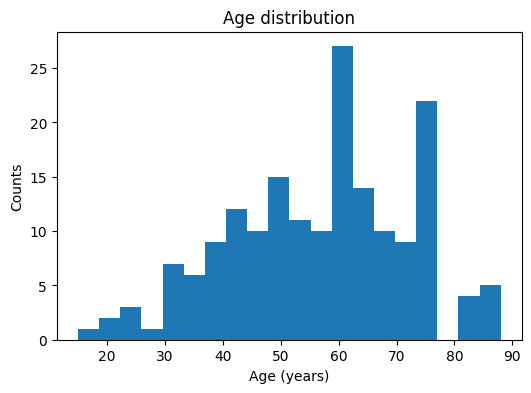

count    178.000000
mean      56.651685
std       15.608270
min       15.000000
25%       46.000000
50%       59.000000
75%       68.000000
max       88.000000
Name: Age, dtype: float64


In [11]:
# Visualize the age distribution
print(data["Age"].isna().sum()) # 3 empty patients
plt.figure(figsize=(6,4))
plt.hist(data["Age"].dropna(), bins=20)
plt.title("Age distribution")
plt.xlabel("Age (years)")
plt.ylabel("Counts")
plt.show()
print(data["Age"].describe())

In [12]:
# Since all the age values are coherent, age is imputed with the mean (57 years)
data["Age"] = data["Age"].fillna(data["Age"].mean())

#### Impute PVC Transition

In [13]:
# Identify the precordial leads, since are the ones needed to calculate the transition
precordials = ["V1", "V2", "V3", "V4", "V5", "V6"]

def compute_transition(row):
    """The transition is computed as the first precordial lead to show a
    larger amplitude in the R wave than the S wave"""
    ratios = []
    for lead in precordials:
        sig = row[lead]

        # If there is a missing lead, don't calculate (shouldn't happen)
        if sig is None or (isinstance(sig, float) and np.isnan(sig)):
            return np.nan

        sig = np.array(sig, dtype=float)

        R = np.max(sig)          # R peak
        S = abs(np.min(sig))     # S peak

        ratio = np.inf if S == 0 else R / S # Ratio
        ratios.append(ratio)

    ratios = np.array(ratios)

    # First lead where R >= S, or R/S >= 1
    idx = np.where(ratios >= 1)[0]

    # If it's not found it means it's the 6th lead
    if len(idx) == 0:
        return "V6"
    else:
        return precordials[idx[0]]


# Identify patients with missing PVC transition values
mask = data["PVC_transition"].isna()
print("Cases to impute:", mask.sum())

# Apply the automated transition calculation only to missing entries
data.loc[mask, "PVC_transition"] = data.loc[mask].apply(
    compute_transition,
    axis=1)

# Visualize
print(data["PVC_transition"].isna().sum(), "left NaNs")
print(data.loc[mask, ["PVC_transition"]])

Cases to impute: 5
0 left NaNs
    PVC_transition
20              V2
72              V5
94              V1
111             V4
150             V2


#### Handling height weight and BMI
First, we compute the BMI if height and weight exist.
Then if H or W doesn't exist, they are imputed with sex based mean. Before the reconstruction, the oultiers are assessed to choose if we want to use the mean or median.

In [14]:
# Function to compute BMI and update only if conditions are met (no lists handled)
def compute_bmi(row):
    h = row['Height']
    w = row['Weight']
    b = row['BMI']

    if (
        not pd.isna(h) and
        not pd.isna(w) and
        pd.isna(b)
    ):
        # Height is in cm, we convert it to meters
        height_m = h / 100
        bmi = w / (height_m ** 2)
        return round(bmi, 1)
    else:
        return b  # leave unchanged

# Apply the function to the 'BMI' column
data['BMI'] = data.apply(compute_bmi, axis=1)

display(data[clinical_cols + label_cols].head())

,Sex,HTA,Age,PVC_transition,Height,Weight,BMI,DM,DLP,Smoker,COPD,Sleep_apnea,CLINICAL_SCORE,SOO_chamber,SOO,OTorigin
0,1.0,NaN,61.0,V1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Right ventricle,Unión mitroaórtica,0.0
1,1.0,0.0,52.0,V3,169.0,68.0,23.800000,0.0,0.0,0.0,0.0,0.0,1.0,RVOT,Pared libre anterior,1.0
2,1.0,0.0,69.0,V3,156.0,70.0,28.800000,0.0,1.0,0.0,0.0,0.0,1.0,LVOT,RCC,1.0
3,1.0,0.0,66.0,V4,176.0,63.0,20.338326,0.0,0.0,0.0,0.0,0.0,1.0,Right ventricle,M. papilar posteromedial,0.0
4,1.0,1.0,46.0,V3,160.0,79.0,30.859375,0.0,0.0,0.0,0.0,0.0,1.0,RVOT,RVOT septal,1.0


Height: 0 outliers
Empty DataFrame
Columns: [Height]
Index: []


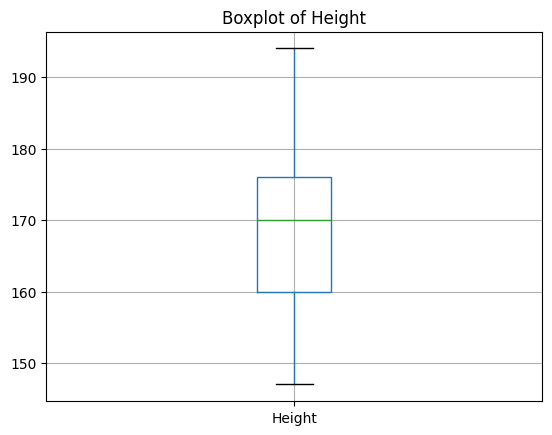

Weight: 4 outliers
     Weight
95    120.0
149   114.0
157   117.0
165   122.0


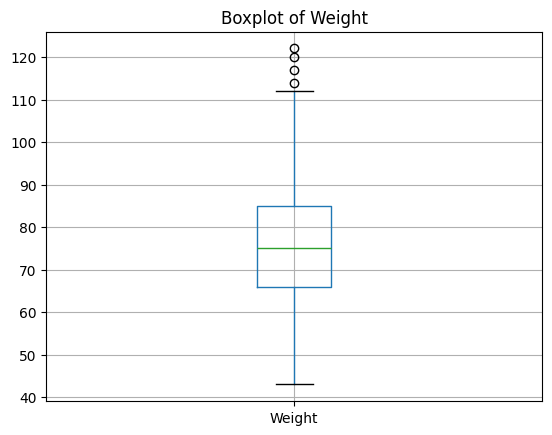

BMI: 3 outliers
           BMI
45   38.754325
112  39.600000
165  38.941556


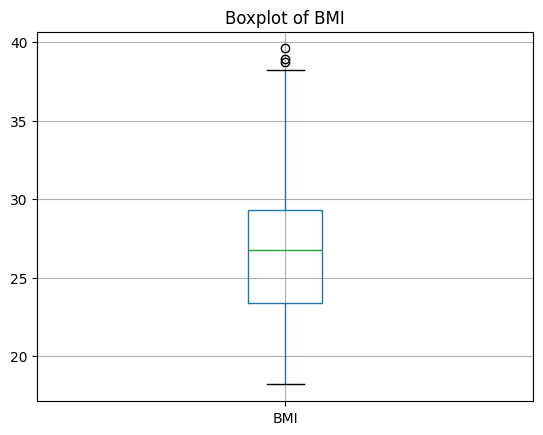

In [15]:
# Identify outliers in Height, Weight and BMI with Interquartile Range method
import matplotlib.pyplot as plt

cols = ['Height', 'Weight', 'BMI']
for col in cols:
    if col in data.columns:
        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers = data[(data[col] < lower_bound) | (data[col] > upper_bound)]
        print(f"{col}: {len(outliers)} outliers")
        print(outliers[[col]])
        # Opcional: visualizar con boxplot
        plt.figure()
        data.boxplot(column=col)
        plt.title(f'Boxplot of {col}')
        plt.show()

In [16]:
# Convert non--> NaN if they weren't yet
data[clinical_cols] = data[clinical_cols].replace("None", np.nan)

# Define the columns to study
cols = ["Height", "Weight"]

for col in cols:
    print("\n" + "="*50)
    print(col.upper())
    print("="*50)

    print("Missing values:", data[col].isna().sum())
    print("Mean:", round(data[col].mean(), 2))
    print("Median:", round(data[col].median(), 2))
    print("Std:", round(data[col].std(), 2))
    print("Min:", round(data[col].min(), 2))
    print("Max:", round(data[col].max(), 2))

    # Print by sex to impute by sex
    print("\nBy Sex:")
    display(
        data.groupby("Sex")[col]
        .agg(["count","mean","median","std","min","max"])
        .round(2)
    )


HEIGHT
Missing values: 28
Mean: 169.25
Median: 170.0
Std: 9.71
Min: 147.0
Max: 194.0

By Sex:


,count,mean,median,std,min,max
Sex,,,,,,
0.0,77,175.29,175.0,8.43,149.0,194.0
1.0,76,163.13,162.0,6.62,147.0,176.0



WEIGHT
Missing values: 28
Mean: 76.67
Median: 75.0
Std: 15.06
Min: 43.0
Max: 122.0

By Sex:


,count,mean,median,std,min,max
Sex,,,,,,
0.0,78,85.67,84.0,14.02,43.0,122.0
1.0,75,67.31,67.0,9.33,48.0,100.0


Height and weight were imputed using sex-stratified median values. The median was preferred over the mean due to its robustness to potential outliers, particularly in weight, where a right-skewed distribution and extreme values were observed (max = 122 kg).

In [17]:
print(data["Sex"].value_counts(dropna=False))

Sex
0.0    93
1.0    86
NaN     2
Name: count, dtype: int64


In [18]:
# If sex exists, impute by sex
data["Height"] = data["Height"].fillna(
    data.groupby("Sex")["Height"].transform("median"))

data["Weight"] = data["Weight"].fillna(
    data.groupby("Sex")["Weight"].transform("median"))

# For patients without specified sex, impute with global median
data["Height"] = data["Height"].fillna(data["Height"].median())
data["Weight"] = data["Weight"].fillna(data["Weight"].median())

# Calcualte BMI for imputed patients
data["BMI"] = data["Weight"] / (data["Height"]/100)**2

### Homogenizing Labels


--- Missing per variable ---
Sleep_apnea       8
Smoker            8
COPD              7
DM                7
CLINICAL_SCORE    7
HTA               6
DLP               6
Height            0
Weight            0
BMI               0

--- Patient Summary ---
Pacients  with a missing: 9
Completed patients: 172

--- Detailed missing values ---


,n_missing,missing_cols
0,7,"HTA, DM, DLP, Smoker, COPD, Sleep_apnea, CLINI..."
14,7,"HTA, DM, DLP, Smoker, COPD, Sleep_apnea, CLINI..."
111,7,"HTA, DM, DLP, Smoker, COPD, Sleep_apnea, CLINI..."
146,7,"HTA, DM, DLP, Smoker, COPD, Sleep_apnea, CLINI..."
128,7,"HTA, DM, DLP, Smoker, COPD, Sleep_apnea, CLINI..."
171,7,"HTA, DM, DLP, Smoker, COPD, Sleep_apnea, CLINI..."
53,3,"DM, Smoker, Sleep_apnea"
119,3,"Smoker, COPD, Sleep_apnea"
50,1,CLINICAL_SCORE


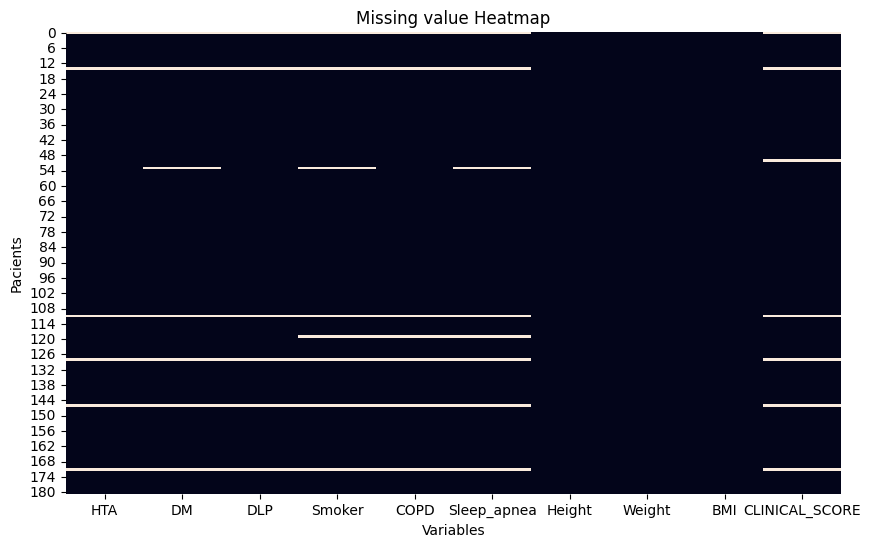

In [19]:
cols = all_clinical_cols

# Print missing data per variable
missing_var = data[cols].isna().sum().sort_values(ascending=False)

print("\n--- Missing per variable ---")
print(missing_var.to_string())


# Global summary
mask_missing = data[cols].isna().any(axis=1)

print("\n--- Patient Summary ---")
print(f"Pacients  with a missing: {mask_missing.sum()}")
print(f"Completed patients: {(~mask_missing).sum()}")


# Per patient summary
resumen = pd.DataFrame({
    "n_missing": data[cols].isna().sum(axis=1),
    "missing_cols": data[cols].isna().apply(lambda x: ", ".join(x.index[x]), axis=1)})

resumen = resumen[resumen["n_missing"] > 0].sort_values("n_missing", ascending=False)

print("\n--- Detailed missing values ---")
display(resumen)


# Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(data[cols].isna(), cbar=False)
plt.title("Missing value Heatmap")
plt.xlabel("Variables")
plt.ylabel("Pacients")
plt.show()

In [20]:
# See the possible labels
display(data[clinical_cols + label_cols].head())

,Sex,HTA,Age,PVC_transition,Height,Weight,BMI,DM,DLP,Smoker,COPD,Sleep_apnea,CLINICAL_SCORE,SOO_chamber,SOO,OTorigin
0,1.0,NaN,61.0,V1,162.0,67.0,25.529645,NaN,NaN,NaN,NaN,NaN,NaN,Right ventricle,Unión mitroaórtica,0.0
1,1.0,0.0,52.0,V3,169.0,68.0,23.808690,0.0,0.0,0.0,0.0,0.0,1.0,RVOT,Pared libre anterior,1.0
2,1.0,0.0,69.0,V3,156.0,70.0,28.763971,0.0,1.0,0.0,0.0,0.0,1.0,LVOT,RCC,1.0
3,1.0,0.0,66.0,V4,176.0,63.0,20.338326,0.0,0.0,0.0,0.0,0.0,1.0,Right ventricle,M. papilar posteromedial,0.0
4,1.0,1.0,46.0,V3,160.0,79.0,30.859375,0.0,0.0,0.0,0.0,0.0,1.0,RVOT,RVOT septal,1.0


In [21]:
# Print the number of unique labels (If it's not 7 we need to homogenize)
soo_unique = data["SOO"].dropna().unique()
print("Unique existing labels:", len(soo_unique))


Unique existing labels: 90


In [22]:
# Load and print the Excel file
labels_sheet2 = pd.read_excel(labels2_path)
labels_sheet2 = pd.DataFrame(labels_sheet2)
labels_sheet2.dropna(inplace=True)
display(labels_sheet2)

,OTorigin,SOO_chamber,SOO,Simplified
0,1.0,RVOT,RVOT lateral medio,RVOTFREEWALL
2,1.0,RVOT,RVOT anteroseptal subvalvular,RVOTSEPTUM
3,1.0,LVOT,LVOT cúspide derecha (cerca de la comisura),RCC
4,0.0,Tricuspid annulus,Anillo tricuspídeo lateral,RVOTSEPTUM
6,0.0,Right ventricle,VI laterobasal,LVOTSUBVALVULAR
...,...,...,...,...
290,1.0,LVOT,Intersinus,COMMISURE
291,1.0,LVOT,RCC,RCC
292,1.0,RVOT,RVOT,RVOTFREEWALL
293,1.0,LVOT,Summit,LVOTSUMMIT


In [23]:
# Create a mapping dictionary from the labels_sheet1 DataFrame
soo_to_simplified = labels_sheet2.set_index('SOO')['Simplified'].to_dict()
soo_to_simplified["Ostium de SC"] = "LVOTSUMMIT"
data = data[data["SOO"] != "anillo lat"]

# Map the 'SOO' column in the data DataFrame to the corresponding 'Simplified' value
data['Final_Label'] = data['SOO'].map(soo_to_simplified)
# Handle the specific case where the value in 'SOO' is 'rvot sèeto posterior'
data.loc[data['SOO'] == 'rvot sèeto posterior', 'Final_Label'] = 'RVOTSEPTUM'
# Display the updated DataFrame
display(data[clinical_cols + label_cols].head())

,Sex,HTA,Age,PVC_transition,Height,Weight,BMI,DM,DLP,Smoker,COPD,Sleep_apnea,CLINICAL_SCORE,SOO_chamber,SOO,OTorigin
0,1.0,NaN,61.0,V1,162.0,67.0,25.529645,NaN,NaN,NaN,NaN,NaN,NaN,Right ventricle,Unión mitroaórtica,0.0
1,1.0,0.0,52.0,V3,169.0,68.0,23.808690,0.0,0.0,0.0,0.0,0.0,1.0,RVOT,Pared libre anterior,1.0
2,1.0,0.0,69.0,V3,156.0,70.0,28.763971,0.0,1.0,0.0,0.0,0.0,1.0,LVOT,RCC,1.0
3,1.0,0.0,66.0,V4,176.0,63.0,20.338326,0.0,0.0,0.0,0.0,0.0,1.0,Right ventricle,M. papilar posteromedial,0.0
4,1.0,1.0,46.0,V3,160.0,79.0,30.859375,0.0,0.0,0.0,0.0,0.0,1.0,RVOT,RVOT septal,1.0


In [24]:
print("Total:", len(data))
print("Mapped:", data["Final_Label"].notna().sum())
print("Unmapped:", data["Final_Label"].isna().sum())

Total: 180
Mapped: 179
Unmapped: 1


In [25]:
unmapped = data.loc[data["Final_Label"].isna(), "SOO"].unique()

print("No mapeados:", len(unmapped))
for x in sorted(unmapped):
    print(x)

No mapeados: 1
nan


In [26]:
labels_sheet1 = pd.read_excel(labels_path)
labels_sheet1 = pd.DataFrame(labels_sheet1)
labels_sheet1.dropna(inplace=True)
display(labels_sheet1)

,SOO,SOO_Chamber,Automatic_SOO,Region_Simplified
0,LVOT cúspide derecha (cerca de la comisura),LVOT,RCC,RCC
1,RVOT supravalvular anterolateral,RVOT,RVOT Anterior,RVOTFREEWALL
2,RVOT anterior,RVOT,RVOT Anterior,RVOTFREEWALL
3,RVOT posteroseptal,RVOT,RVOT LateroSeptal,RVOTSEPTUM
4,LVOT intersenos de Valsalva dcho-izdo,LVOT,Intersinus,COMMISSURE
...,...,...,...,...
114,Postero Septal Subvalvular,RVOT,RVOT Septal,RVOTSEPTUM
115,RCC,LVOT,RCC,RCC
116,RVOT,RVOT,RVOT Lateral,RVOTFREEWALL
117,Summit,LVOT,LVOT Summit,SUMMIT


In [27]:
# Create a mapping dictionary from the labels_sheet1 DataFrame
final_label_to_chamber = labels_sheet1.set_index('Region_Simplified')['SOO_Chamber'].to_dict()

# Replace all occurrences of 'Commisure' with 'Commissure' in the dataframe
data["Final_Label"] = data["Final_Label"].replace({
    "COMMISURE": "COMMISSURE"
})
# Map the 'Final_Label' column in the data DataFrame to the corresponding 'SOO_Chamber' value
data['Chamber_Type'] = data['Final_Label'].map(final_label_to_chamber)
data.loc[data['Final_Label'] == 'LVOTSUMMIT', 'Chamber_Type'] = 'LVOT'
# Display the updated DataFrame
# display(data)

In [28]:
# Drop the specified columns from the dataframe
data.drop(columns=['SOO_chamber', 'SOO', 'OTorigin'], inplace=True)

# Display the updated dataframe
display(data)

,patient_id,I,II,III,AVR,AVL,AVF,V1,V2,V3,...,BMI,DM,DLP,Smoker,COPD,Sleep_apnea,CLINICAL_SCORE,missing_rate,Final_Label,Chamber_Type
0,0,"[-0.018000000000000002, -0.021, -0.01800000000...","[-0.042, -0.039, -0.036000000000000004, -0.033...","[-0.021, -0.018000000000000002, -0.01800000000...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.003, 0.006, 0.0090...","[0.03, 0.03, 0.03, 0.027, 0.024, 0.021, 0.0180...","[-0.033, -0.03, -0.027, -0.024, -0.024, -0.027...","[0.018000000000000002, 0.018000000000000002, 0...","[-0.06, -0.057, -0.054, -0.051000000000000004,...","[-0.06, -0.06, -0.057, -0.054, -0.054, -0.0510...",...,25.529645,NaN,NaN,NaN,NaN,NaN,NaN,1.0,LVOTSUBVALVULAR,LVOT
1,1,"[-0.018000000000000002, -0.018000000000000002,...","[-0.042, -0.042, -0.042, -0.042, -0.042, -0.04...","[-0.021, -0.021, -0.021, -0.024, -0.024, -0.02...","[0.0, 0.0, 0.0, 0.003, 0.003, 0.003, 0.003, 0....","[0.03, 0.03, 0.03, 0.027, 0.027, 0.027, 0.03, ...","[-0.03, -0.03, -0.03, -0.03, -0.033, -0.033, -...","[0.045, 0.045, 0.045, 0.045, 0.045, 0.045, 0.0...","[-0.036000000000000004, -0.039, -0.039, -0.042...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, -0.003, -0...",...,23.808690,0.0,0.0,0.0,0.0,0.0,1.0,0.1,RVOTFREEWALL,RVOT
2,2,"[0.015, 0.012, 0.009000000000000001, 0.0090000...","[0.0, 0.006, 0.006, 0.003, 0.0, 0.0, -0.003, -...","[-0.009000000000000001, -0.006, -0.003, -0.003...","[0.012, 0.009000000000000001, 0.006, 0.006, 0....","[-0.009000000000000001, -0.009000000000000001,...","[-0.003, 0.0, 0.0, 0.0, -0.003, -0.006, -0.006...","[-0.093, -0.096, -0.096, -0.099, -0.096, -0.09...","[-0.123, -0.126, -0.129, -0.129, -0.129, -0.12...","[-0.153, -0.156, -0.159, -0.162, -0.159, -0.15...",...,28.763971,0.0,1.0,0.0,0.0,0.0,1.0,0.1,RCC,LVOT
3,3,"[-0.036000000000000004, -0.033, -0.033, -0.033...","[-0.147, -0.147, -0.147, -0.147, -0.147, -0.14...","[-0.111, -0.111, -0.111, -0.111, -0.114, -0.11...","[0.036000000000000004, 0.039, 0.039, 0.039, 0....","[0.09, 0.09, 0.09, 0.09, 0.09, 0.09, 0.09, 0.0...","[-0.129, -0.129, -0.129, -0.129, -0.129, -0.12...","[0.024, 0.024, 0.024, 0.024, 0.024, 0.027, 0.0...","[0.027, 0.027, 0.027, 0.027, 0.027, 0.027, 0.0...","[-0.063, -0.063, -0.063, -0.063, -0.063, -0.06...",...,20.338326,0.0,0.0,0.0,0.0,0.0,1.0,0.0,RVOTFREEWALL,RVOT
4,4,"[-0.009000000000000001, -0.006, 0.0, 0.0, 0.00...","[0.903, 0.894, 0.888, 0.879, 0.867, 0.852, 0.8...","[0.912, 0.9, 0.888, 0.876, 0.864, 0.846, 0.825...","[-0.462, -0.453, -0.444, -0.438, -0.426, -0.41...","[-0.444, -0.444, -0.441, -0.438, -0.435, -0.42...","[0.906, 0.897, 0.888, 0.879, 0.864, 0.849, 0.8...","[-0.183, -0.192, -0.20700000000000002, -0.234,...","[0.066, 0.084, 0.10200000000000001, 0.117, 0.1...","[0.27, 0.261, 0.258, 0.252, 0.24, 0.225, 0.207...",...,30.859375,0.0,0.0,0.0,0.0,0.0,1.0,0.0,RVOTSEPTUM,RVOT
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
176,176,"[0.063, 0.084, 0.10200000000000001, 0.111, 0.1...","[-0.10200000000000001, -0.09, -0.078, -0.078, ...","[-0.14400000000000002, -0.129, -0.114, -0.108,...","[0.08700000000000001, 0.084, 0.081, 0.075, 0.0...","[0.027, 0.009000000000000001, -0.006, -0.012, ...","[-0.12, -0.10200000000000001, -0.0870000000000...","[-0.096, -0.096, -0.096, -0.08700000000000001,...","[0.006, 0.003, 0.003, 0.006, 0.006, 0.006, 0.0...","[-0.183, -0.171, -0.159, -0.147, -0.138, -0.12...",...,25.464011,0.0,0.0,0.0,0.0,0.0,3.0,0.0,LVOTSUMMIT,LVOT
177,177,"[-0.024, -0.03, -0.036000000000000004, -0.0360...","[-0.012, -0.021, -0.027, -0.021, -0.012, -0.01...","[0.018000000000000002, 0.012, 0.012, 0.015, 0....","[-0.018000000000000002, -0.015, -0.01800000000...","[0.018000000000000002, 0.027, 0.033, 0.033, 0....","[0.0, -0.009000000000000001, -0.015, -0.012, -...","[0.0, 0.006, 0.006, 0.003, 0.003, 0.003, 0.0, ...","[-0.054, -0.048, -0.042, -0.039, -0.039, -0.04...","[-0.06, -0.057, -0.054, -0.048, -0.048, -0.051...",...,25.057360,0.0,0.0,0.0,0.0,0.0,3.0,0.0,RCC,LVOT
178,178,"[-0.009000000000000001, -0.009000000000000001,...","[-0.

In [29]:
# Convert the 'Chamber_Type' column to binary
data["Chamber_Type"] = (data["Chamber_Type"] == "RVOT").astype(int)
cols_interes = ["Final_Label", "Chamber_Type"]

display(data[cols_interes])

# Display the updated DataFrame
# display(data)

,Final_Label,Chamber_Type
0,LVOTSUBVALVULAR,0
1,RVOTFREEWALL,1
2,RCC,0
3,RVOTFREEWALL,1
4,RVOTSEPTUM,1
...,...,...
176,LVOTSUMMIT,0
177,RCC,0
178,LVOTSUBVALVULAR,0
179,LVOTSUBVALVULAR,0


In [30]:
print("Missing target:", data["Chamber_Type"].isna().sum())
print(data["Chamber_Type"].value_counts())

Missing target: 0
Chamber_Type
1    103
0     77
Name: count, dtype: int64


In [31]:
# Instead of one-hot-encoding we use ordinal encoding to reduce dimentionality!!

data["PVC_transition"] = data["PVC_transition"].map({
    "V1": 1,
    "V2": 2,
    "V3": 3,
    "V4": 4,
    "V5": 5,
    "V6": 6
})

display(data)

,patient_id,I,II,III,AVR,AVL,AVF,V1,V2,V3,...,BMI,DM,DLP,Smoker,COPD,Sleep_apnea,CLINICAL_SCORE,missing_rate,Final_Label,Chamber_Type
0,0,"[-0.018000000000000002, -0.021, -0.01800000000...","[-0.042, -0.039, -0.036000000000000004, -0.033...","[-0.021, -0.018000000000000002, -0.01800000000...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.003, 0.006, 0.0090...","[0.03, 0.03, 0.03, 0.027, 0.024, 0.021, 0.0180...","[-0.033, -0.03, -0.027, -0.024, -0.024, -0.027...","[0.018000000000000002, 0.018000000000000002, 0...","[-0.06, -0.057, -0.054, -0.051000000000000004,...","[-0.06, -0.06, -0.057, -0.054, -0.054, -0.0510...",...,25.529645,NaN,NaN,NaN,NaN,NaN,NaN,1.0,LVOTSUBVALVULAR,0
1,1,"[-0.018000000000000002, -0.018000000000000002,...","[-0.042, -0.042, -0.042, -0.042, -0.042, -0.04...","[-0.021, -0.021, -0.021, -0.024, -0.024, -0.02...","[0.0, 0.0, 0.0, 0.003, 0.003, 0.003, 0.003, 0....","[0.03, 0.03, 0.03, 0.027, 0.027, 0.027, 0.03, ...","[-0.03, -0.03, -0.03, -0.03, -0.033, -0.033, -...","[0.045, 0.045, 0.045, 0.045, 0.045, 0.045, 0.0...","[-0.036000000000000004, -0.039, -0.039, -0.042...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, -0.003, -0...",...,23.808690,0.0,0.0,0.0,0.0,0.0,1.0,0.1,RVOTFREEWALL,1
2,2,"[0.015, 0.012, 0.009000000000000001, 0.0090000...","[0.0, 0.006, 0.006, 0.003, 0.0, 0.0, -0.003, -...","[-0.009000000000000001, -0.006, -0.003, -0.003...","[0.012, 0.009000000000000001, 0.006, 0.006, 0....","[-0.009000000000000001, -0.009000000000000001,...","[-0.003, 0.0, 0.0, 0.0, -0.003, -0.006, -0.006...","[-0.093, -0.096, -0.096, -0.099, -0.096, -0.09...","[-0.123, -0.126, -0.129, -0.129, -0.129, -0.12...","[-0.153, -0.156, -0.159, -0.162, -0.159, -0.15...",...,28.763971,0.0,1.0,0.0,0.0,0.0,1.0,0.1,RCC,0
3,3,"[-0.036000000000000004, -0.033, -0.033, -0.033...","[-0.147, -0.147, -0.147, -0.147, -0.147, -0.14...","[-0.111, -0.111, -0.111, -0.111, -0.114, -0.11...","[0.036000000000000004, 0.039, 0.039, 0.039, 0....","[0.09, 0.09, 0.09, 0.09, 0.09, 0.09, 0.09, 0.0...","[-0.129, -0.129, -0.129, -0.129, -0.129, -0.12...","[0.024, 0.024, 0.024, 0.024, 0.024, 0.027, 0.0...","[0.027, 0.027, 0.027, 0.027, 0.027, 0.027, 0.0...","[-0.063, -0.063, -0.063, -0.063, -0.063, -0.06...",...,20.338326,0.0,0.0,0.0,0.0,0.0,1.0,0.0,RVOTFREEWALL,1
4,4,"[-0.009000000000000001, -0.006, 0.0, 0.0, 0.00...","[0.903, 0.894, 0.888, 0.879, 0.867, 0.852, 0.8...","[0.912, 0.9, 0.888, 0.876, 0.864, 0.846, 0.825...","[-0.462, -0.453, -0.444, -0.438, -0.426, -0.41...","[-0.444, -0.444, -0.441, -0.438, -0.435, -0.42...","[0.906, 0.897, 0.888, 0.879, 0.864, 0.849, 0.8...","[-0.183, -0.192, -0.20700000000000002, -0.234,...","[0.066, 0.084, 0.10200000000000001, 0.117, 0.1...","[0.27, 0.261, 0.258, 0.252, 0.24, 0.225, 0.207...",...,30.859375,0.0,0.0,0.0,0.0,0.0,1.0,0.0,RVOTSEPTUM,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
176,176,"[0.063, 0.084, 0.10200000000000001, 0.111, 0.1...","[-0.10200000000000001, -0.09, -0.078, -0.078, ...","[-0.14400000000000002, -0.129, -0.114, -0.108,...","[0.08700000000000001, 0.084, 0.081, 0.075, 0.0...","[0.027, 0.009000000000000001, -0.006, -0.012, ...","[-0.12, -0.10200000000000001, -0.0870000000000...","[-0.096, -0.096, -0.096, -0.08700000000000001,...","[0.006, 0.003, 0.003, 0.006, 0.006, 0.006, 0.0...","[-0.183, -0.171, -0.159, -0.147, -0.138, -0.12...",...,25.464011,0.0,0.0,0.0,0.0,0.0,3.0,0.0,LVOTSUMMIT,0
177,177,"[-0.024, -0.03, -0.036000000000000004, -0.0360...","[-0.012, -0.021, -0.027, -0.021, -0.012, -0.01...","[0.018000000000000002, 0.012, 0.012, 0.015, 0....","[-0.018000000000000002, -0.015, -0.01800000000...","[0.018000000000000002, 0.027, 0.033, 0.033, 0....","[0.0, -0.009000000000000001, -0.015, -0.012, -...","[0.0, 0.006, 0.006, 0.003, 0.003, 0.003, 0.0, ...","[-0.054, -0.048, -0.042, -0.039, -0.039, -0.04...","[-0.06, -0.057, -0.054, -0.048, -0.048, -0.051...",...,25.057360,0.0,0.0,0.0,0.0,0.0,3.0,0.0,RCC,0
178,178,"[-0.009000000000000001, -0.009000000000000001,...","[-0.048, -0.045, -0.042, 

In [32]:
# Create target dataframe
Y = pd.DataFrame({
    'Patient_ID': data.index,
    'Chamber_Type': data['Chamber_Type'].values
})


In [35]:
# Create a tabular only dataset without ecg cols
data_tabular = data.drop(columns=[
    "I","II","III","AVR","AVL","AVF",
    "V1","V2","V3","V4","V5","V6"])
data_tabular.to_pickle(os.path.join(base_path, "data/tabular_dataset.pkl"))
data_tabular.to_parquet(os.path.join(base_path,"data/tabular_dataset.parquet"))


# Create a dataset without final label (only include binary labels)
demographic_data_LVOT_RVOT = data.drop(columns=['Final_Label'], errors='ignore')
demographic_data_LVOT_RVOT.to_pickle(os.path.join(base_path,"data/binary_full_dataset.pkl"))
demographic_data_LVOT_RVOT.to_parquet(os.path.join(base_path,"data/binary_full_dataset.parquet"))


# Create a multiclass dataset with the final label (SOO simplified)
multiclass_data = data.drop(columns=['Chamber_Type'], errors='ignore')
multiclass_data.to_pickle(os.path.join(base_path,"data/multiclass_full_dataset.pkl"))
multiclass_data.to_parquet(os.path.join(base_path,"data/multiclass_full_dataset.parquet"))


In [39]:
df = pd.read_pickle(os.path.join(base_path,"data/binary_full_dataset.pkl"))
display(df)

,patient_id,I,II,III,AVR,AVL,AVF,V1,V2,V3,...,Weight,BMI,DM,DLP,Smoker,COPD,Sleep_apnea,CLINICAL_SCORE,missing_rate,Chamber_Type
0,0,"[-0.018000000000000002, -0.021, -0.01800000000...","[-0.042, -0.039, -0.036000000000000004, -0.033...","[-0.021, -0.018000000000000002, -0.01800000000...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.003, 0.006, 0.0090...","[0.03, 0.03, 0.03, 0.027, 0.024, 0.021, 0.0180...","[-0.033, -0.03, -0.027, -0.024, -0.024, -0.027...","[0.018000000000000002, 0.018000000000000002, 0...","[-0.06, -0.057, -0.054, -0.051000000000000004,...","[-0.06, -0.06, -0.057, -0.054, -0.054, -0.0510...",...,67.0,25.529645,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0
1,1,"[-0.018000000000000002, -0.018000000000000002,...","[-0.042, -0.042, -0.042, -0.042, -0.042, -0.04...","[-0.021, -0.021, -0.021, -0.024, -0.024, -0.02...","[0.0, 0.0, 0.0, 0.003, 0.003, 0.003, 0.003, 0....","[0.03, 0.03, 0.03, 0.027, 0.027, 0.027, 0.03, ...","[-0.03, -0.03, -0.03, -0.03, -0.033, -0.033, -...","[0.045, 0.045, 0.045, 0.045, 0.045, 0.045, 0.0...","[-0.036000000000000004, -0.039, -0.039, -0.042...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, -0.003, -0...",...,68.0,23.808690,0.0,0.0,0.0,0.0,0.0,1.0,0.1,1
2,2,"[0.015, 0.012, 0.009000000000000001, 0.0090000...","[0.0, 0.006, 0.006, 0.003, 0.0, 0.0, -0.003, -...","[-0.009000000000000001, -0.006, -0.003, -0.003...","[0.012, 0.009000000000000001, 0.006, 0.006, 0....","[-0.009000000000000001, -0.009000000000000001,...","[-0.003, 0.0, 0.0, 0.0, -0.003, -0.006, -0.006...","[-0.093, -0.096, -0.096, -0.099, -0.096, -0.09...","[-0.123, -0.126, -0.129, -0.129, -0.129, -0.12...","[-0.153, -0.156, -0.159, -0.162, -0.159, -0.15...",...,70.0,28.763971,0.0,1.0,0.0,0.0,0.0,1.0,0.1,0
3,3,"[-0.036000000000000004, -0.033, -0.033, -0.033...","[-0.147, -0.147, -0.147, -0.147, -0.147, -0.14...","[-0.111, -0.111, -0.111, -0.111, -0.114, -0.11...","[0.036000000000000004, 0.039, 0.039, 0.039, 0....","[0.09, 0.09, 0.09, 0.09, 0.09, 0.09, 0.09, 0.0...","[-0.129, -0.129, -0.129, -0.129, -0.129, -0.12...","[0.024, 0.024, 0.024, 0.024, 0.024, 0.027, 0.0...","[0.027, 0.027, 0.027, 0.027, 0.027, 0.027, 0.0...","[-0.063, -0.063, -0.063, -0.063, -0.063, -0.06...",...,63.0,20.338326,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1
4,4,"[-0.009000000000000001, -0.006, 0.0, 0.0, 0.00...","[0.903, 0.894, 0.888, 0.879, 0.867, 0.852, 0.8...","[0.912, 0.9, 0.888, 0.876, 0.864, 0.846, 0.825...","[-0.462, -0.453, -0.444, -0.438, -0.426, -0.41...","[-0.444, -0.444, -0.441, -0.438, -0.435, -0.42...","[0.906, 0.897, 0.888, 0.879, 0.864, 0.849, 0.8...","[-0.183, -0.192, -0.20700000000000002, -0.234,...","[0.066, 0.084, 0.10200000000000001, 0.117, 0.1...","[0.27, 0.261, 0.258, 0.252, 0.24, 0.225, 0.207...",...,79.0,30.859375,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
176,176,"[0.063, 0.084, 0.10200000000000001, 0.111, 0.1...","[-0.10200000000000001, -0.09, -0.078, -0.078, ...","[-0.14400000000000002, -0.129, -0.114, -0.108,...","[0.08700000000000001, 0.084, 0.081, 0.075, 0.0...","[0.027, 0.009000000000000001, -0.006, -0.012, ...","[-0.12, -0.10200000000000001, -0.0870000000000...","[-0.096, -0.096, -0.096, -0.08700000000000001,...","[0.006, 0.003, 0.003, 0.006, 0.006, 0.006, 0.0...","[-0.183, -0.171, -0.159, -0.147, -0.138, -0.12...",...,90.0,25.464011,0.0,0.0,0.0,0.0,0.0,3.0,0.0,0
177,177,"[-0.024, -0.03, -0.036000000000000004, -0.0360...","[-0.012, -0.021, -0.027, -0.021, -0.012, -0.01...","[0.018000000000000002, 0.012, 0.012, 0.015, 0....","[-0.018000000000000002, -0.015, -0.01800000000...","[0.018000000000000002, 0.027, 0.033, 0.033, 0....","[0.0, -0.009000000000000001, -0.015, -0.012, -...","[0.0, 0.006, 0.006, 0.003, 0.003, 0.003, 0.0, ...","[-0.054, -0.048, -0.042, -0.039, -0.039, -0.04...","[-0.06, -0.057, -0.054, -0.048, -0.048, -0.051...",...,83.0,25.057360,0.0,0.0,0.0,0.0,0.0,3.0,0.0,0
178,178,"[-0.009000000000000001, -0.009000000000000001,...","[-0.048, -0.045, -0.042, -0.042, -0.045, -0.05...","[-0.03600000000